In [65]:
import os

from dotenv import load_dotenv

load_dotenv()
from typing_extensions import Annotated

if os.environ["GOOGLE_API_KEY"]:
    print("GOOGLE_API_KEY is set")
else:
    raise ValueError("GOOGLE_API_KEY is not set")

GOOGLE_API_KEY is set


In [66]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

## llm pydantic schema


In [67]:
from pydantic import BaseModel, Field
from typing import Literal as literal
class llm_schema(BaseModel):
    category: literal['insta','twitter','linkedin'] = Field(..., description="category of the post to generarte")
    topic: str = Field(..., description="Topic of the post to generate")
    

In [68]:
llm_with_schema = model.with_structured_output(llm_schema)

In [69]:
llm_with_schema.invoke("create a post about the importance of data privacy in the digital age for twitter and  insta")

llm_schema(category='twitter', topic='The importance of data privacy in the digital age')

In [70]:
from typing import TypedDict,List , Annotated

class graph_Schema(TypedDict):
    input : str
    topic:str
    post : str
    category : str


In [71]:
def decider_node(state:graph_Schema)->graph_Schema:
    user_input = state["input"]
    result = llm_with_schema.invoke(user_input)
    topic = result.topic
    category = result.category

    state["topic"] = topic
    state["category"] = category
    return state


def create_post_insta(state: graph_Schema)->graph_Schema:

    #convert the model into dict
    # state=state.model_dump()

    #extract the topic from the state
    topic = state["topic"]

    #passing the topic to llm  to generate a linkedin post
    post = model.invoke(f"create an instagram post about {topic} and keep the tone casual and engaging")
    post = post.content[0]["text"]

    #updating the post with genrated post
    state["post"] = post

    return {'post': post}
    



def create_post_twitter(state: graph_Schema)->graph_Schema:

    #convert the model into dict
    

    #extract the topic from the state
    topic = state["topic"]

    #passing the topic to llm  to generate a linkedin post
    post = model.invoke(f"create an twitter post about {topic} and keep the tone quick")
    post = post.content[0]["text"]

    #updating the post with genrated post
    state["post"] = post

    return  {'post': post}

def create_post_linkedin(state: graph_Schema)->graph_Schema:

    #convert the model into dict
  

    #extract the topic from the state
    topic = state["topic"]

    #passing the topic to llm  to generate a linkedin post
    post = model.invoke(f"create an linkedin post about {topic} and keep the tone professional")
    post = post.content[0]["text"]

    #updating the post with genrated post
    state["post"] = post

    return {'post': post}
    





    







In [72]:
def condition(state: graph_Schema) -> str:

    category = state['category']

    if category == 'insta':
        return 'create_insta'
    elif category == 'twitter':
        return 'create_twitter'
    elif category == 'linkedin':
        return 'create_linkedin'
    else:
        raise ValueError("Invalid category")

In [73]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_Schema)



graph.add_node("decider", decider_node)
graph.add_node("create_insta", create_post_insta)
graph.add_node("create_twitter", create_post_twitter)
graph.add_node("create_linkedin", create_post_linkedin)


graph.add_edge(START, "decider")
graph.add_conditional_edges("decider",condition,{
    'create_insta': "create_insta",
    'create_twitter': "create_twitter",
    'create_linkedin': "create_linkedin"
})

graph.add_edge("create_insta", END)
graph.add_edge("create_twitter", END)
graph.add_edge("create_linkedin", END) 



pydantic_graph = graph.compile()

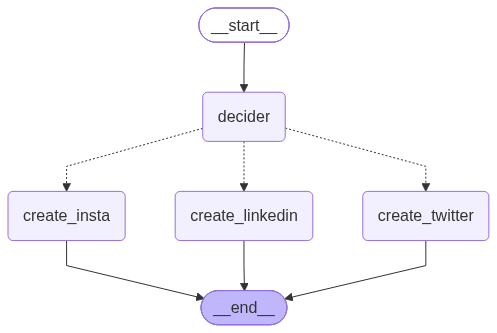

In [74]:
from IPython.display import display,Image

#you could see the error with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [75]:
pydantic_graph.invoke({
    "input": "I want to generate a post for twitter about AI",
    "topic":"",
    "post":"",
    "category":""
})



{'input': 'I want to generate a post for twitter about AI',
 'topic': 'AI',
 'post': "AI isn't coming for your job. \n\nIt's coming for the boring parts of your job. \n\nAdapt or get left behind. 🤖💨",
 'category': 'twitter'}